In [10]:
import pandas as pd

In [11]:
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [12]:
df=pd.read_csv("/content/reviews_data.csv")

In [13]:
df

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...
...,...,...,...,...,...,...
845,Becky,"Agoura Hills, CA","Reviewed July 13, 2006",NaN,I ordered two venti frappacino's without whipp...,['No Images']
846,Bob,"Goodrich, MI","Reviewed Jan. 3, 2005",NaN,No Review Text,['No Images']
847,Erik,"Valley Village, CA","Reviewed Nov. 5, 2004",NaN,"DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...",['No Images']
848,Andrew,"Fallbrook, CA","Reviewed Oct. 20, 2004",NaN,No Review Text,['No Images']


In [14]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download("omw-1.4")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [15]:
df = df.drop(columns=['Date', 'Rating', 'Image_Links'])
display(df.head())

,name,location,Review
0,Helen,"Wichita Falls, TX",Amber and LaDonna at the Starbucks on Southwes...
1,Courtney,"Apopka, FL",** at the Starbucks by the fire station on 436...
2,Daynelle,"Cranberry Twp, PA",I just wanted to go out of my way to recognize...
3,Taylor,"Seattle, WA",Me and my friend were at Starbucks and my card...
4,Tenessa,"Gresham, OR",I’m on this kick of drinking 5 cups of warm wa...


In [16]:
df['tokens'] = df['Review'].apply(word_tokenize)
print("Tokens for the first 5 reviews:")
for i in range(5):
    print(f"Review {i+1}: {df['tokens'].iloc[i]}")

Tokens for the first 5 reviews:
Review 1: ['Amber', 'and', 'LaDonna', 'at', 'the', 'Starbucks', 'on', 'Southwest', 'Parkway', 'are', 'always', 'so', 'warm', 'and', 'welcoming', '.', 'There', 'is', 'always', 'a', 'smile', 'in', 'their', 'voice', 'when', 'they', 'greet', 'you', 'at', 'the', 'drive-thru', '.', 'And', 'their', 'customer', 'service', 'is', 'always', 'spot-on', ',', 'they', 'always', 'get', 'my', 'order', 'right', 'and', 'with', 'a', 'smile', '.', 'I', 'would', 'actually', 'give', 'them', 'more', 'than', '5', 'stars', 'if', 'they', 'were', 'available', '.']
Review 2: ['*', '*', 'at', 'the', 'Starbucks', 'by', 'the', 'fire', 'station', 'on', '436', 'in', 'Altamonte', 'Springs', ',', 'FL', 'made', 'my', 'day', 'and', 'finally', 'helped', 'me', 'figure', 'out', 'the', 'way', 'to', 'make', 'my', 'drink', 'so', 'I', '’', 'd', 'love', 'it', '.', 'She', 'took', 'time', 'out', 'to', 'talk', 'to', 'me', 'for', '2', 'minutes', 'to', 'make', 'my', 'experience', 'better', 'than', 'what'

In [17]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)

print("Before and After Stopword Removal for the first 5 reviews:")
for i in range(5):
    print(f"\nReview {i+1}:")
    print(f"Original Tokens: {df['tokens'].iloc[i]}")
    print(f"Filtered Tokens: {df['filtered_tokens'].iloc[i]}")

Before and After Stopword Removal for the first 5 reviews:

Review 1:
Original Tokens: ['Amber', 'and', 'LaDonna', 'at', 'the', 'Starbucks', 'on', 'Southwest', 'Parkway', 'are', 'always', 'so', 'warm', 'and', 'welcoming', '.', 'There', 'is', 'always', 'a', 'smile', 'in', 'their', 'voice', 'when', 'they', 'greet', 'you', 'at', 'the', 'drive-thru', '.', 'And', 'their', 'customer', 'service', 'is', 'always', 'spot-on', ',', 'they', 'always', 'get', 'my', 'order', 'right', 'and', 'with', 'a', 'smile', '.', 'I', 'would', 'actually', 'give', 'them', 'more', 'than', '5', 'stars', 'if', 'they', 'were', 'available', '.']
Filtered Tokens: ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', '.', 'always', 'smile', 'voice', 'greet', 'drive-thru', '.', 'customer', 'service', 'always', 'spot-on', ',', 'always', 'get', 'order', 'right', 'smile', '.', 'would', 'actually', 'give', '5', 'stars', 'available', '.']

Review 2:
Original Tokens: ['*', '*', 'at', 'the', 'S

In [19]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def stem_tokens(tokens):
    return [ps.stem(word) for word in tokens]

df['stemmed_tokens'] = df['filtered_tokens'].apply(stem_tokens)

print("Stemmed Tokens for the first 10 reviews:")
for i in range(10):
    print(f"\nReview {i+1}:")
    print(f"Original Filtered Tokens: {df['filtered_tokens'].iloc[i]}")
    print(f"Stemmed Tokens: {df['stemmed_tokens'].iloc[i]}")

Stemmed Tokens for the first 10 reviews:

Review 1:
Original Filtered Tokens: ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', '.', 'always', 'smile', 'voice', 'greet', 'drive-thru', '.', 'customer', 'service', 'always', 'spot-on', ',', 'always', 'get', 'order', 'right', 'smile', '.', 'would', 'actually', 'give', '5', 'stars', 'available', '.']
Stemmed Tokens: ['amber', 'ladonna', 'starbuck', 'southwest', 'parkway', 'alway', 'warm', 'welcom', '.', 'alway', 'smile', 'voic', 'greet', 'drive-thru', '.', 'custom', 'servic', 'alway', 'spot-on', ',', 'alway', 'get', 'order', 'right', 'smile', '.', 'would', 'actual', 'give', '5', 'star', 'avail', '.']

Review 2:
Original Filtered Tokens: ['*', '*', 'Starbucks', 'fire', 'station', '436', 'Altamonte', 'Springs', ',', 'FL', 'made', 'day', 'finally', 'helped', 'figure', 'way', 'make', 'drink', '’', 'love', '.', 'took', 'time', 'talk', '2', 'minutes', 'make', 'experience', 'better', '’', 'used', '.', 'much',

In [20]:
wnl = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [wnl.lemmatize(word) for word in tokens]

df['lemmatized_tokens'] = df['filtered_tokens'].apply(lemmatize_tokens)

print("Comparison of Filtered, Stemmed, and Lemmatized Tokens (first 10 reviews):")
for i in range(10):
    print(f"\nReview {i+1}:")
    print(f"Filtered Tokens: {df['filtered_tokens'].iloc[i]}")
    print(f"Stemmed Tokens: {df['stemmed_tokens'].iloc[i]}")
    print(f"Lemmatized Tokens: {df['lemmatized_tokens'].iloc[i]}")

Comparison of Filtered, Stemmed, and Lemmatized Tokens (first 10 reviews):

Review 1:
Filtered Tokens: ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', '.', 'always', 'smile', 'voice', 'greet', 'drive-thru', '.', 'customer', 'service', 'always', 'spot-on', ',', 'always', 'get', 'order', 'right', 'smile', '.', 'would', 'actually', 'give', '5', 'stars', 'available', '.']
Stemmed Tokens: ['amber', 'ladonna', 'starbuck', 'southwest', 'parkway', 'alway', 'warm', 'welcom', '.', 'alway', 'smile', 'voic', 'greet', 'drive-thru', '.', 'custom', 'servic', 'alway', 'spot-on', ',', 'alway', 'get', 'order', 'right', 'smile', '.', 'would', 'actual', 'give', '5', 'star', 'avail', '.']
Lemmatized Tokens: ['Amber', 'LaDonna', 'Starbucks', 'Southwest', 'Parkway', 'always', 'warm', 'welcoming', '.', 'always', 'smile', 'voice', 'greet', 'drive-thru', '.', 'customer', 'service', 'always', 'spot-on', ',', 'always', 'get', 'order', 'right', 'smile', '.', 'would', 'actua

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Join the lemmatized tokens back into a string for CountVectorizer
df['lemmatized_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the lemmatized text
X = vectorizer.fit_transform(df['lemmatized_text'])

# Display vocabulary
print("\nVocabulary (first 20 items):\n", list(vectorizer.vocabulary_.items())[:20])

# Display feature names
print("\nFeature Names (first 20 items):\n", vectorizer.get_feature_names_out()[:20])

# Display the matrix shape
print("\nShape of the CountVectorizer matrix:\n", X.shape)

# Display a sample of the matrix (e.g., first 5 rows and first 20 columns if available)
print("\nSample of the CountVectorizer matrix (first 5 rows, first 20 columns):\n")
# Convert sparse matrix to dense for easier printing of a slice
# This might be memory intensive for very large matrices, but fine for a sample
if X.shape[1] > 20:
    display(pd.DataFrame(X[:5, :20].toarray(), columns=vectorizer.get_feature_names_out()[:20]))
else:
    display(pd.DataFrame(X[:5, :].toarray(), columns=vectorizer.get_feature_names_out()))


Vocabulary (first 20 items):
 [('amber', 451), ('ladonna', 2763), ('starbucks', 4587), ('southwest', 4511), ('parkway', 3484), ('always', 447), ('warm', 5270), ('welcoming', 5317), ('smile', 4440), ('voice', 5233), ('greet', 2250), ('drive', 1657), ('thru', 4876), ('customer', 1378), ('service', 4292), ('spot', 4562), ('on', 3370), ('get', 2181), ('order', 3394), ('right', 4085)]

Feature Names (first 20 items):
 ['00' '000' '000php' '00am' '01' '02' '02239' '0266' '03' '04' '0403907'
 '05' '06' '06486' '07' '08' '09' '10' '100' '1000']

Shape of the CountVectorizer matrix:
 (850, 5452)

Sample of the CountVectorizer matrix (first 5 rows, first 20 columns):



,00,000,000php,00am,01,02,02239,0266,03,04,0403907,05,06,06486,07,08,09,10,100,1000
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,1
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Ensure 'lemmatized_text' column is available
# If it's not, you might need to re-run previous steps or ensure 'lemmatized_tokens' is processed
if 'lemmatized_tokens' not in df.columns:
    print("Error: 'lemmatized_tokens' column not found. Please ensure lemmatization step is executed.")
else:
    df['lemmatized_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

    # Initialize TfidfVectorizer
    tfidf_vectorizer = TfidfVectorizer()

    # Fit and transform the lemmatized text
    X_tfidf = tfidf_vectorizer.fit_transform(df['lemmatized_text'])

    # Display vocabulary
    print("\nTF-IDF Vocabulary (first 20 items):\n", list(tfidf_vectorizer.vocabulary_.items())[:20])

    # Display feature names
    print("\nTF-IDF Feature Names (first 20 items):\n", tfidf_vectorizer.get_feature_names_out()[:20])

    # Display the TF-IDF matrix shape
    print("\nShape of the TfidfVectorizer matrix:\n", X_tfidf.shape)

    # Display a sample of the TF-IDF matrix (e.g., first 5 rows and first 20 columns if available)
    print("\nSample of the TfidfVectorizer matrix (first 5 rows, first 20 columns):\n")
    # Convert sparse matrix to dense for easier printing of a slice
    # This might be memory intensive for very large matrices, but fine for a sample
    if X_tfidf.shape[1] > 20:
        display(pd.DataFrame(X_tfidf[:5, :20].toarray(), columns=tfidf_vectorizer.get_feature_names_out()[:20]))
    else:
        display(pd.DataFrame(X_tfidf[:5, :].toarray(), columns=tfidf_vectorizer.get_feature_names_out()))


TF-IDF Vocabulary (first 20 items):
 [('amber', 451), ('ladonna', 2763), ('starbucks', 4587), ('southwest', 4511), ('parkway', 3484), ('always', 447), ('warm', 5270), ('welcoming', 5317), ('smile', 4440), ('voice', 5233), ('greet', 2250), ('drive', 1657), ('thru', 4876), ('customer', 1378), ('service', 4292), ('spot', 4562), ('on', 3370), ('get', 2181), ('order', 3394), ('right', 4085)]

TF-IDF Feature Names (first 20 items):
 ['00' '000' '000php' '00am' '01' '02' '02239' '0266' '03' '04' '0403907'
 '05' '06' '06486' '07' '08' '09' '10' '100' '1000']

Shape of the TfidfVectorizer matrix:
 (850, 5452)

Sample of the TfidfVectorizer matrix (first 5 rows, first 20 columns):



,00,000,000php,00am,01,02,02239,0266,03,04,0403907,05,06,06486,07,08,09,10,100,1000
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.323719,0.0,0.190465
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000


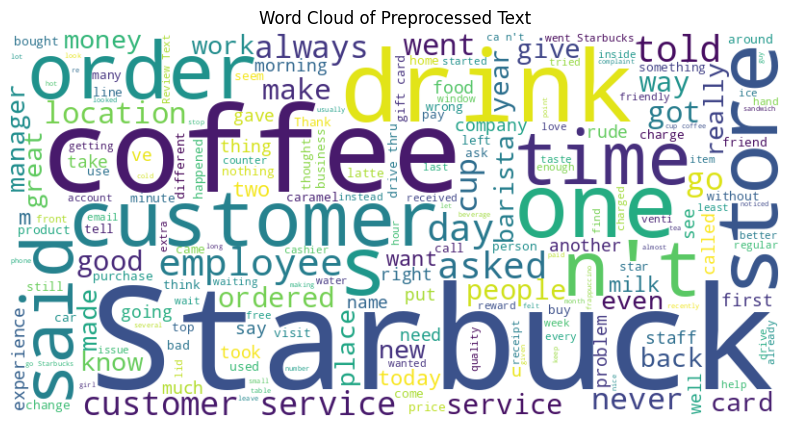

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'lemmatized_text' column is available
# The 'lemmatized_text' column should have been created in a previous step
if 'lemmatized_text' not in df.columns:
    if 'lemmatized_tokens' in df.columns:
        df['lemmatized_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))
    else:
        print("Error: 'lemmatized_tokens' or 'lemmatized_text' column not found. Please ensure lemmatization step is executed.")

if 'lemmatized_text' in df.columns:
    # Concatenate all lemmatized text into one large string
    # Drop any NaN values in case some reviews are empty after preprocessing
    all_lemmatized_words = ' '.join(df['lemmatized_text'].dropna().tolist())

    # Check if the combined string is not empty before generating WordCloud
    if all_lemmatized_words:
        # Generate a word cloud image
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_lemmatized_words)

        # Display the generated image:
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Preprocessed Text')
        plt.show()
    else:
        print("No preprocessed text found to generate a Word Cloud.")
else:
    print("Cannot generate Word Cloud without 'lemmatized_text' column.")